# Week 4 - Univariate Analysis, part 2

# 1. Lesson - None

# 2. Weekly graph question

Below are a histogram and boxplot representation of the same data. A pharmacy is keeping a record of the prices of the drugs that it sells, and an administrator wants to know how much the more expensive drugs tend to cost, in the context of the other prices.

Please write a short explanation of the pros and cons of these two representations. Which would you choose? How would you modify the formatting, if at all, to make it more visually interesting, clear, or informative?

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:

np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size = num_data) * 4)
df = pd.DataFrame(data.T, columns = ["data"])

The 75th percentile is: data    15.457656
Name: 0.75, dtype: float64


<Axes: ylabel='Frequency'>

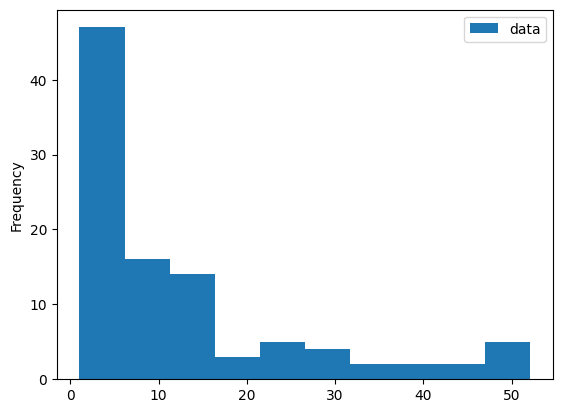

In [3]:
print("The 75th percentile is:", df.quantile(q = 0.75))
df.plot.hist()

<Axes: >

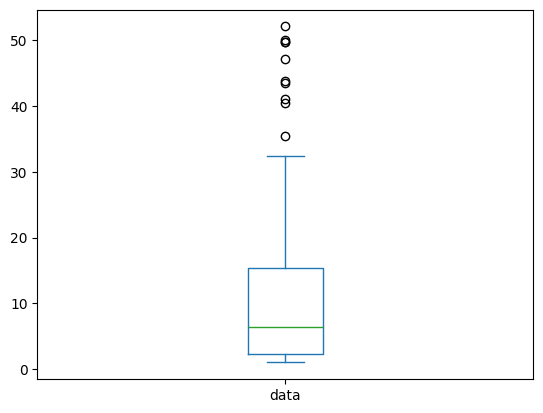

In [4]:
df.plot.box()

# 3. Homework - working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Draw histograms and histogram variants for each feature or column.  (Swarm plot, kde plot, violin plot).

- Draw grouped histograms.  For instance, if you have tree heights for both maple and oak trees, you could draw histograms for both.

- Draw a bar plot to indicate total counts of each categorical variable in a given column.

- Find means, medians, and modes.



# Import cleaned data from week2

In [5]:
# was getting data type warnings on import and so I defined them to clear those
dtype_dict = { 
    'Nationality': str,
    'Naturality.State': str,
    'City.Address': str,
    'Statement': str,
    'Distant.metastasis': str, 
    'Status.Address': str,
    'year': str,     
}

date_cols = ['Date.of.Birth', 'Date.of.Death', 'Date.of.Last.Contact', 'Date.of.Diagnostic']

df = pd.read_csv(
    "df_cleaned.csv", 
    dtype=dtype_dict, 
    parse_dates=date_cols, 
    low_memory=False
)


FileNotFoundError: [Errno 2] No such file or directory: 'df_cleaned.csv'

In [ ]:
df.info()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 1751147 entries, 0 to 1751146
Data columns (total 68 columns):
 #   Column                                              Dtype         
---  ------                                              -----         
 0   Patient.Code                                        float64       
 1   RCBP.Name                                           str           
 2   Date.of.Birth                                       str           
 3   Age                                                 float64       
 4   Nationality                                         str           
 5   Naturality.State                                    str           
 6   Naturality                                          str           
 7   Code.Profession                                     float64       
 8   Name.Occupation                                     str           
 9   Status.Address                                      str           
 10  City.Address                 

,Patient.Code,Age,Code.Profession,Code.of.Morphology,Date.of.Death,Date.of.Last.Contact,Date.of.Diagnostic
count,1.751147e+06,1.751147e+06,1.751147e+06,1.751147e+06,246527,146504,661844
mean,7.109382e+05,6.011253e+01,9.089688e+01,8.285093e+04,2009-04-13 20:11:19.149951,2013-06-19 18:02:43.949107,2008-08-29 12:35:11.163355
min,1.010000e+02,0.000000e+00,0.000000e+00,8.000000e+04,2000-01-01 00:00:00,2000-01-01 00:00:00,2000-01-01 00:00:00
25%,4.547280e+05,5.000000e+01,0.000000e+00,8.070300e+04,2005-03-11 00:00:00,2011-05-12 00:00:00,2004-09-09 00:00:00
50%,6.941985e+05,6.200000e+01,0.000000e+00,8.097300e+04,2009-08-04 00:00:00,2014-02-09 00:00:00,2008-12-11 00:00:00
75%,9.267485e+05,7.200000e+01,0.000000e+00,8.380300e+04,2013-03-04 00:00:00,2016-05-08 00:00:00,2012-07-03 00:00:00
max,1.464035e+06,1.067000e+03,9.920000e+02,9.990300e+04,2021-12-08 00:00:00,2021-12-11 00:00:00,2019-12-12 00:00:00
std,3.309834e+05,1.683805e+01,2.114552e+02,4.294096e+03,NaN,NaN,NaN


# Adding a survival days column as this can be easily calculated and would be interesting to look at

In [ ]:

date_cols = ['Date.of.Diagnostic', 'Date.of.Death']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# 2. Create the Survival_Days column
# Subtracting the dates and converting to a simple integer (days)
df['Survival_Days'] = (df['Date.of.Death'] - df['Date.of.Diagnostic']).dt.days

# 3. Handle 'impossible' data
# We filter out cases where death date is before diagnosis (data entry error)
# Note: Survival_Days will be NaN for patients who are still Alive
df = df[(df['Survival_Days'] >= 0) | (df['Survival_Days'].isna())]

# 4. Create your Plotting-Friendly Target
# This helps with the 'Red/Blue' histograms we made earlier
df['Vital_Status'] = df['Status.Vital_MORTO'].map({True: 'Deceased', False: 'Alive'})

# Draw histograms and histogram variants for each feature or column.  (Swarm plot, kde plot, violin plot).

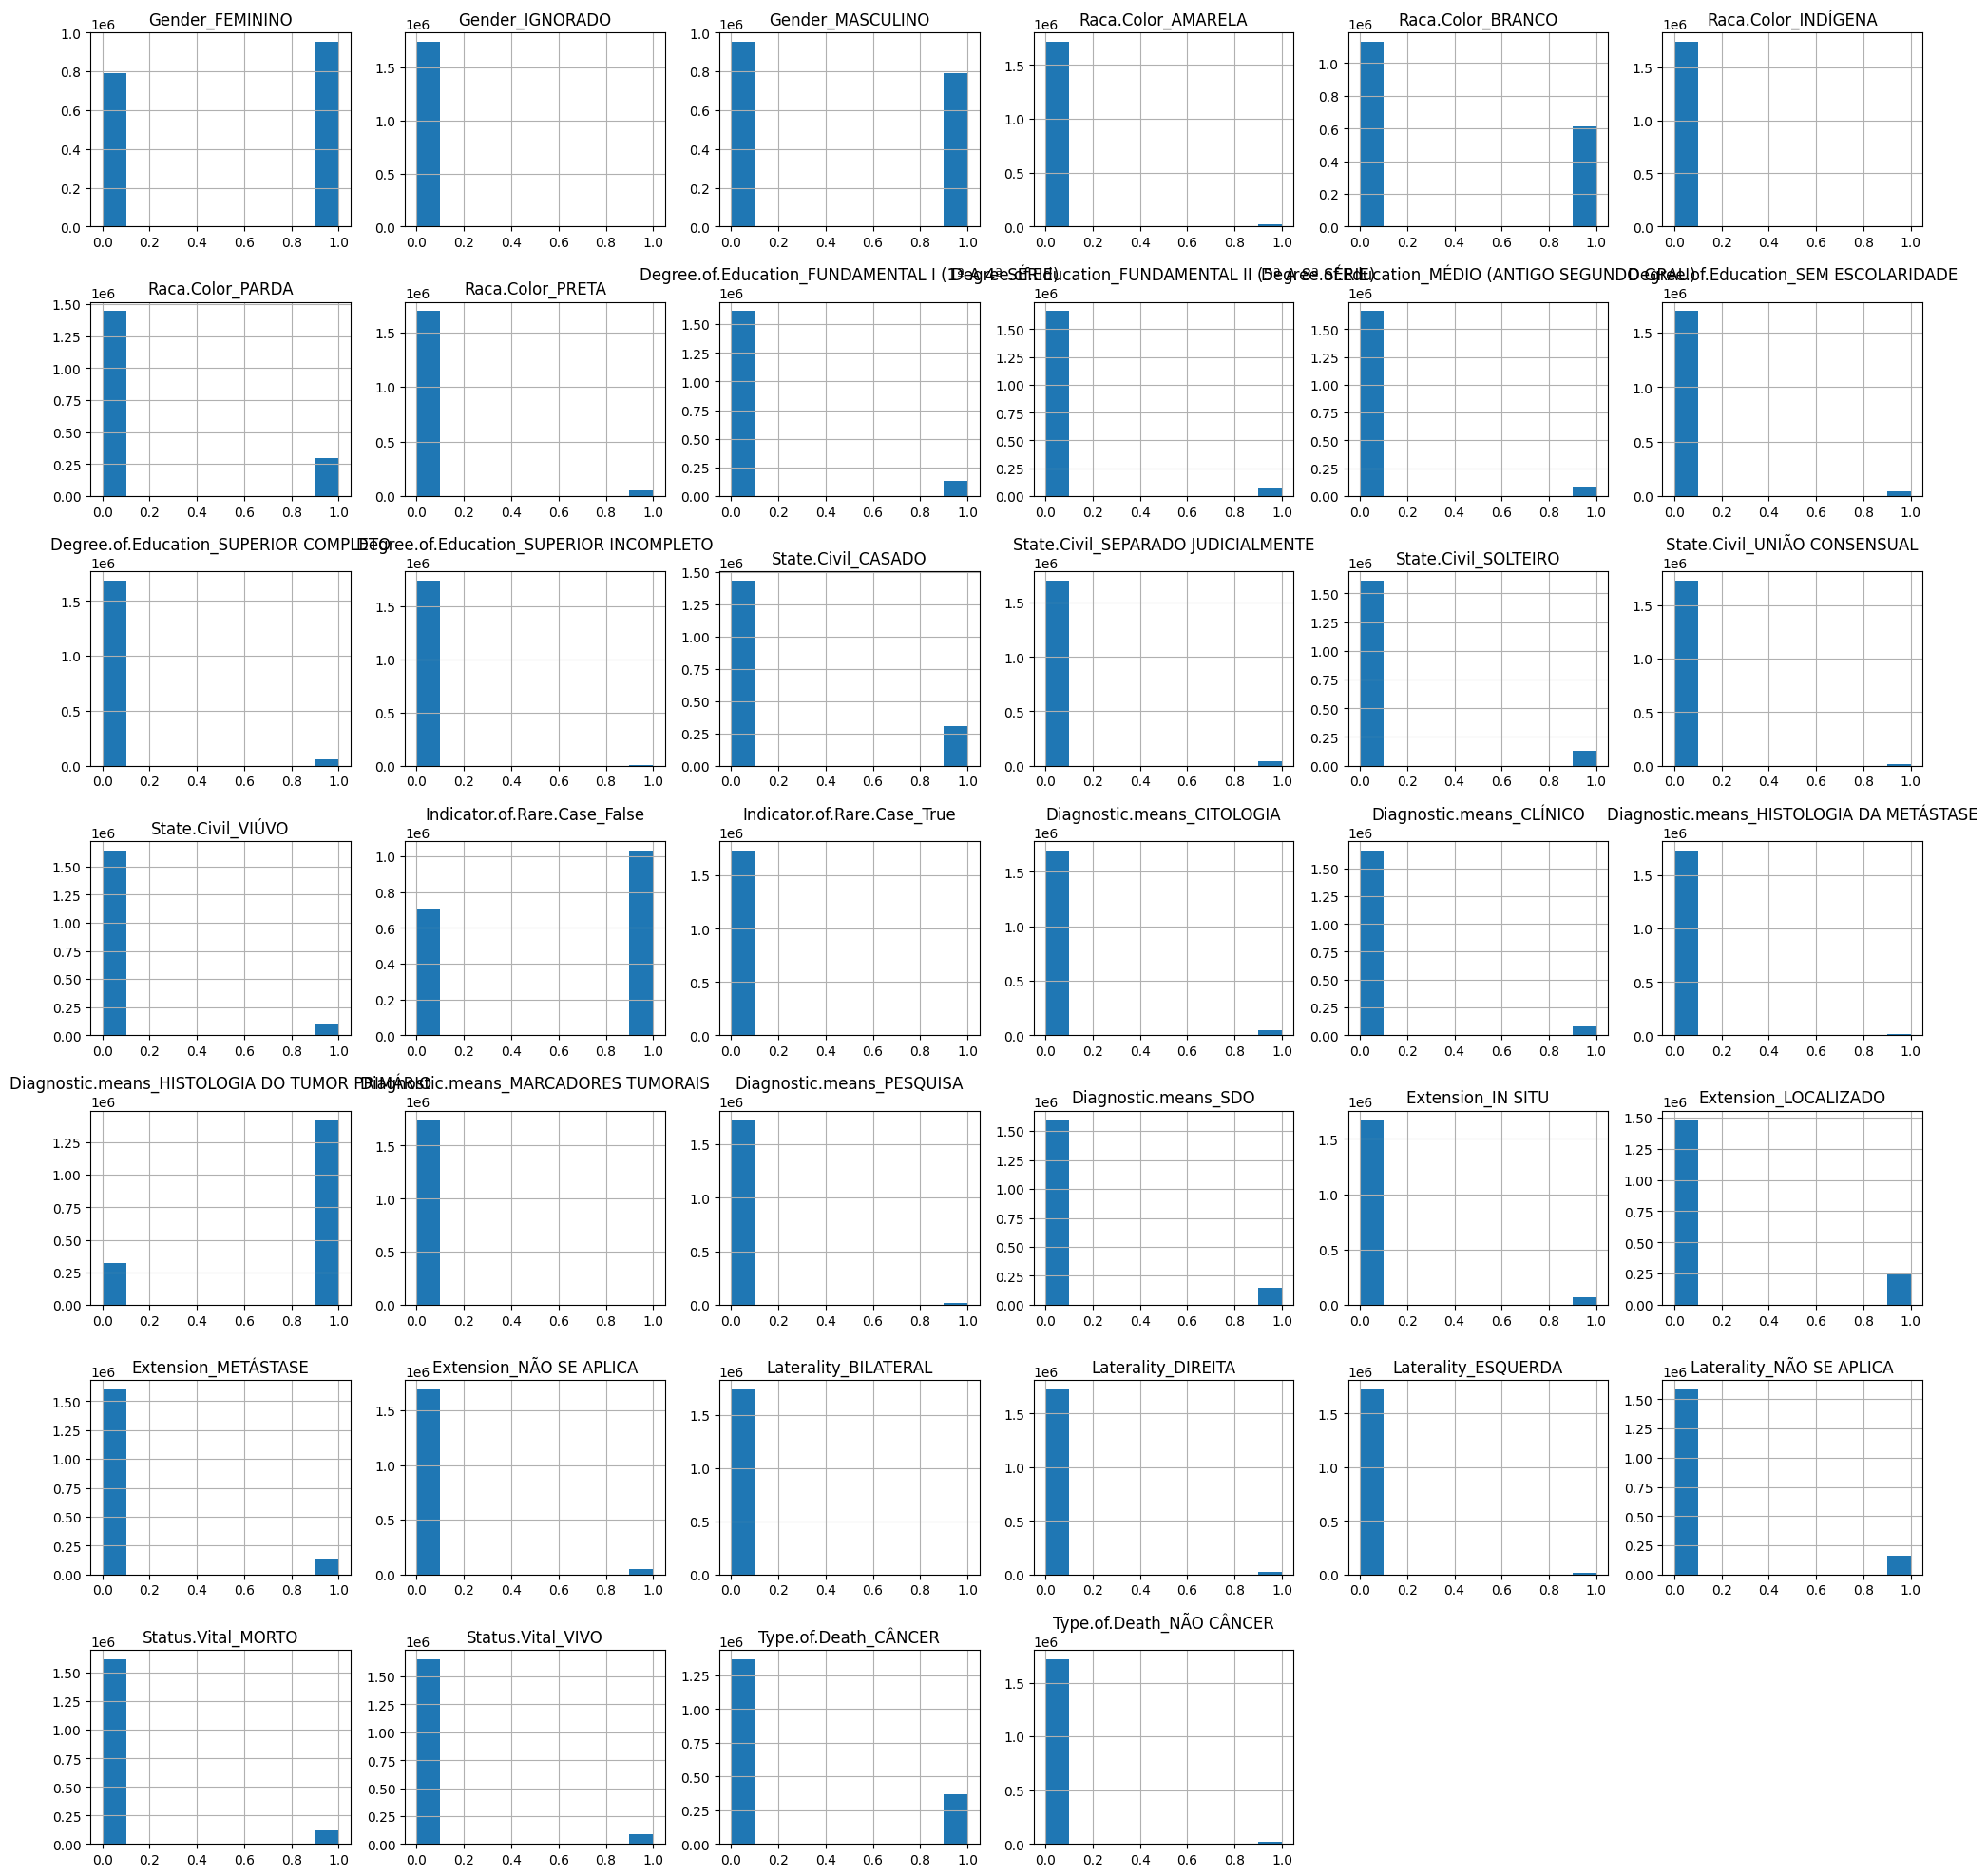

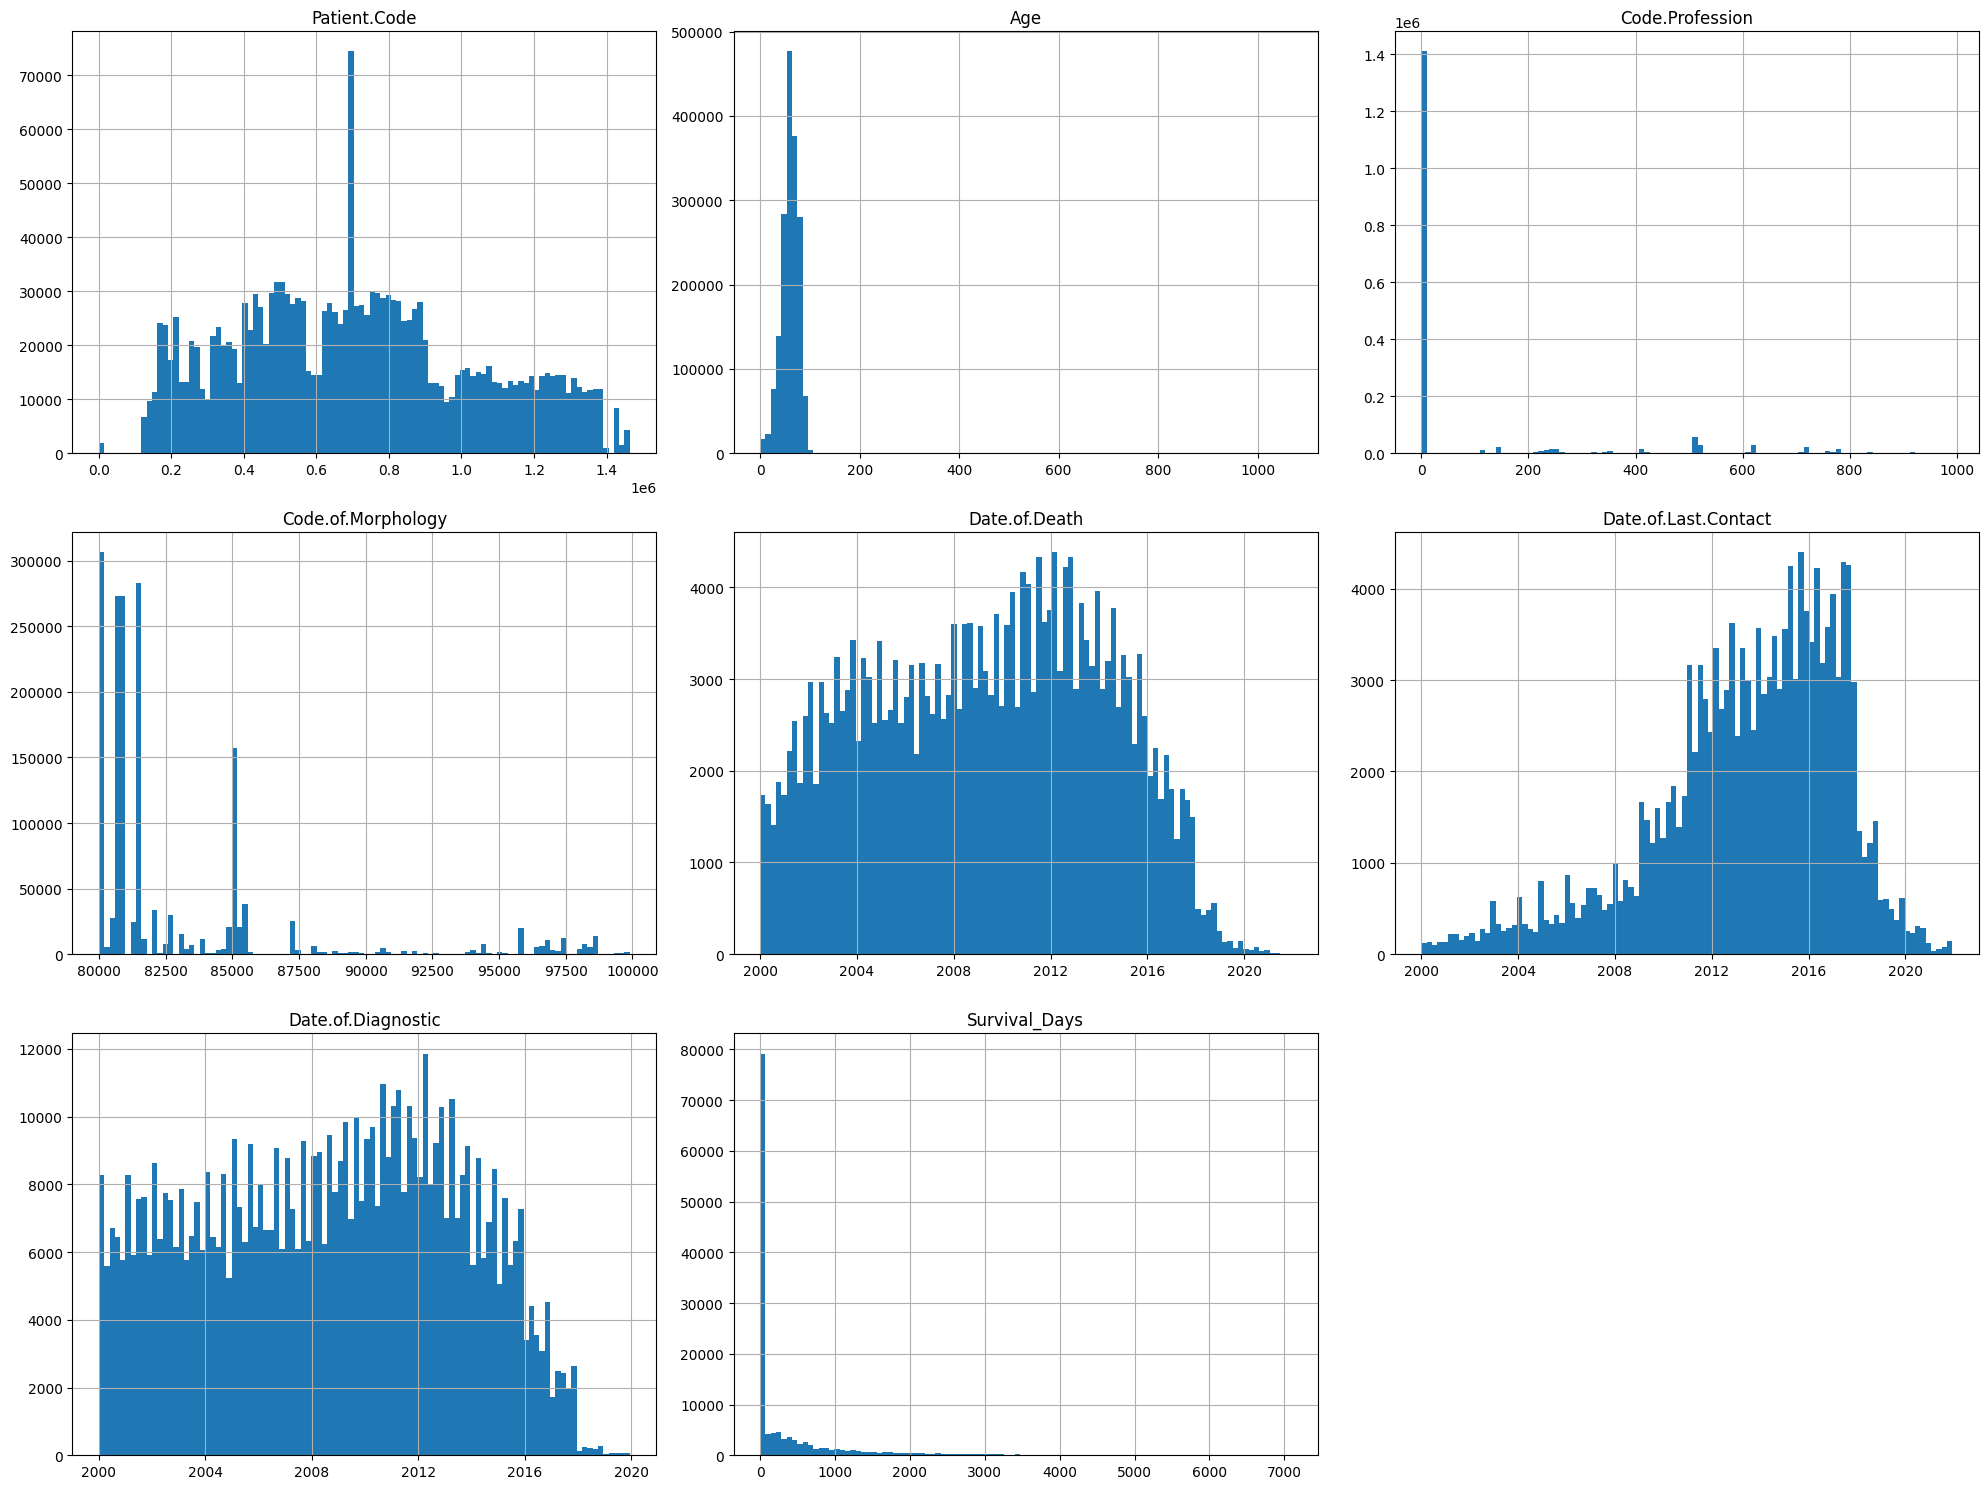

In [ ]:
# 1. Grab all the boolean columns
bool_cols = df.select_dtypes(include=['bool']).columns

# 2. Convert them to 0/1 and plot
df[bool_cols].astype(int).hist(figsize=(20, 20), bins= 10)
plt.tight_layout()

df.hist(figsize=(20, 15), bins=100)
plt.tight_layout() 


# Draw grouped histograms

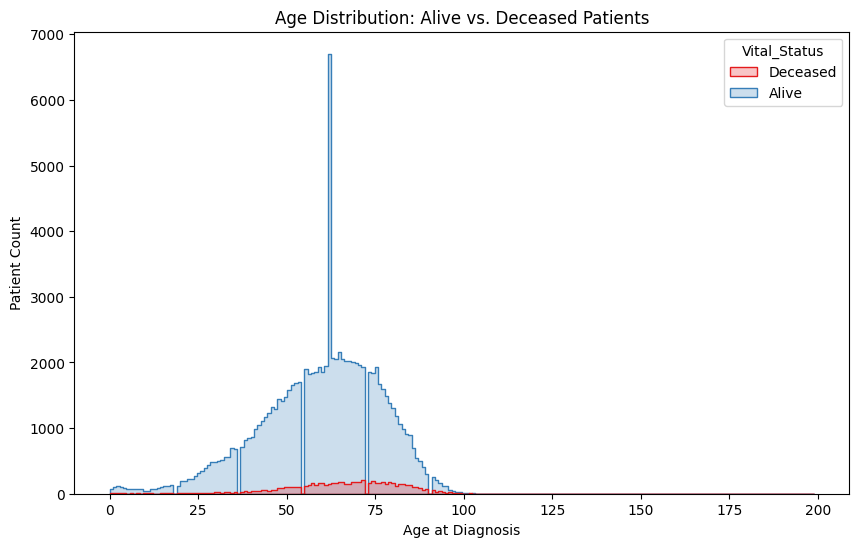

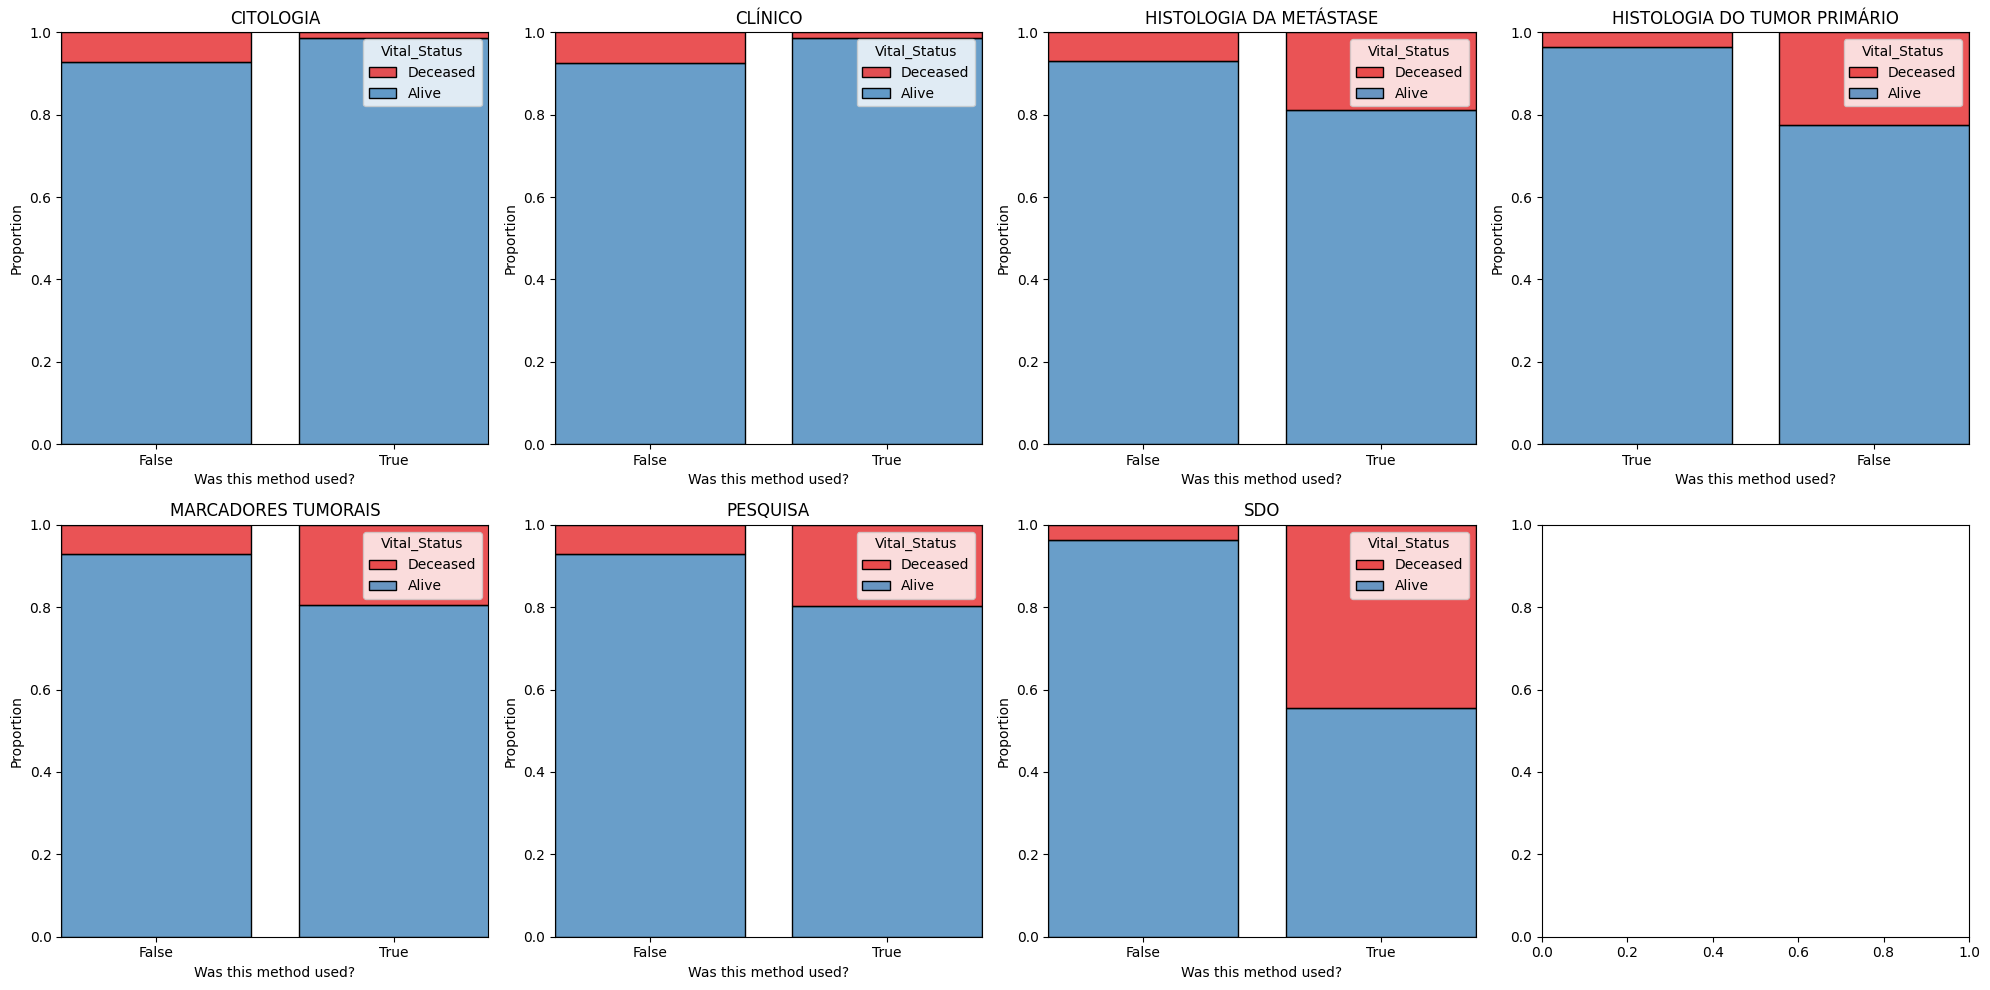

In [ ]:
# Create a readable version for plotting
df['Vital_Status'] = df['Status.Vital_MORTO'].map({True: 'Deceased', False: 'Alive'})


df_sample = df.sample(100000)

plt.figure(figsize=(10, 6))

# 'element="step"' makes the overlapping bars easier to see
sns.histplot(
    data=df_sample, 
    x="Age", 
    hue="Vital_Status", 
    hue_order=['Deceased', 'Alive'],
    element="step", 
    palette="Set1"
)

plt.title("Age Distribution: Alive vs. Deceased Patients")
plt.xlabel("Age at Diagnosis")
plt.ylabel("Patient Count")
plt.show()

# List a few diagnostic boolean columns
diag_cols = [c for c in df.columns if 'Diagnostic.means' in c]


fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(diag_cols):
   
    sns.histplot(
        data=df_sample, 
        x=df_sample[col].astype(str),
        hue="Vital_Status", 
        multiple="fill",   
        hue_order=['Deceased', 'Alive'], 
        palette="Set1", 
        ax=axes[i],
        shrink=0.8        
    )
    
    axes[i].set_title(col.replace('Diagnostic.means_', ''))
    axes[i].set_xlabel('Was this method used?')
    axes[i].set_ylabel('Proportion')

plt.tight_layout()
plt.show()

# Draw a bar plot to indicate total counts of each categorical variable in a given column.

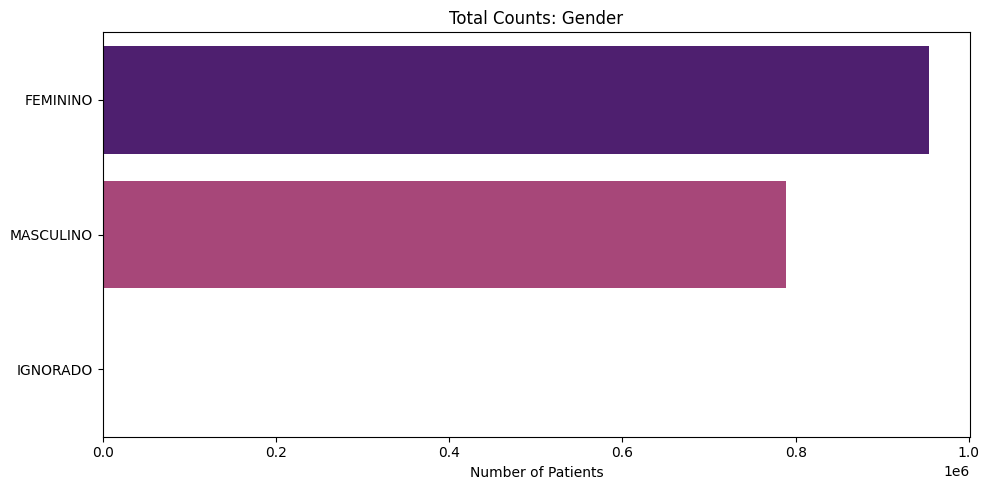

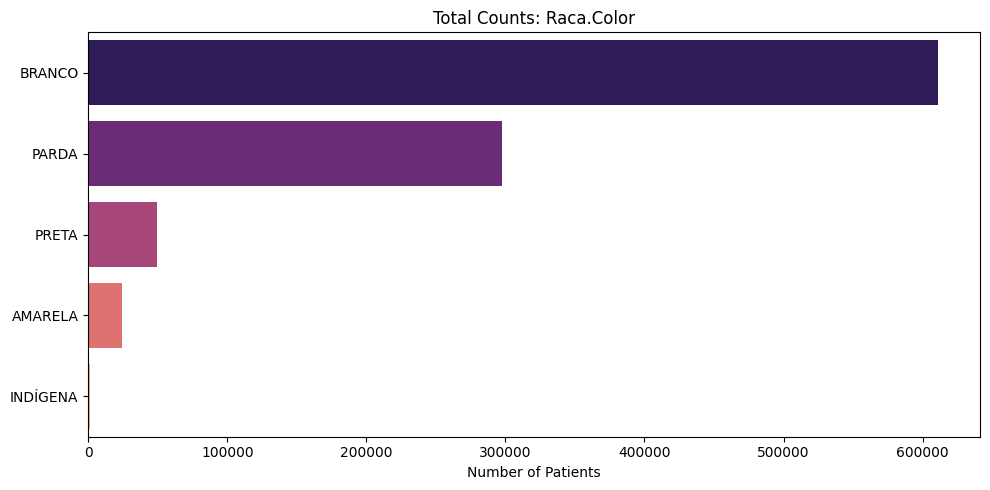

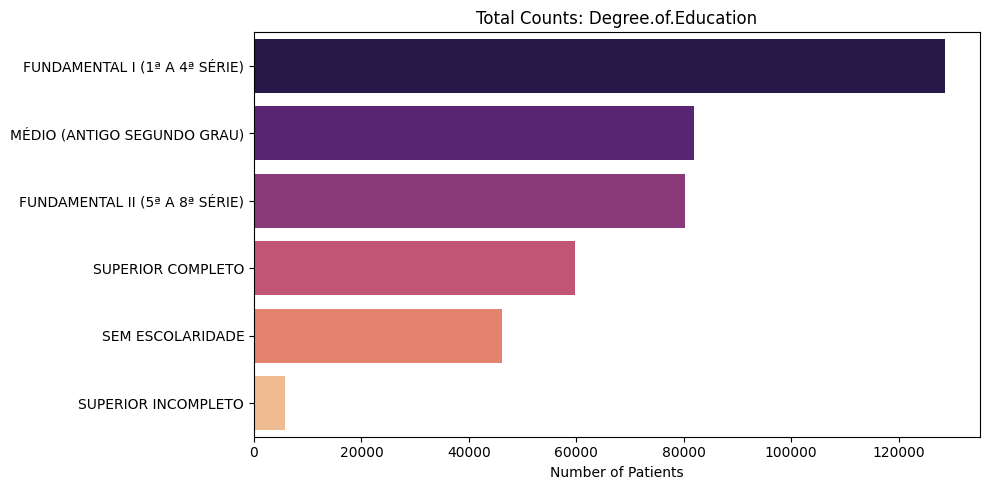

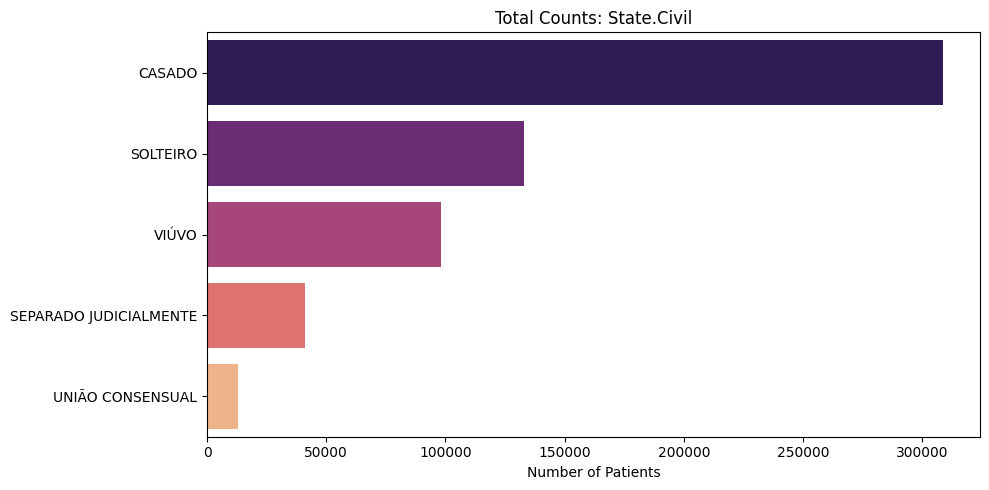

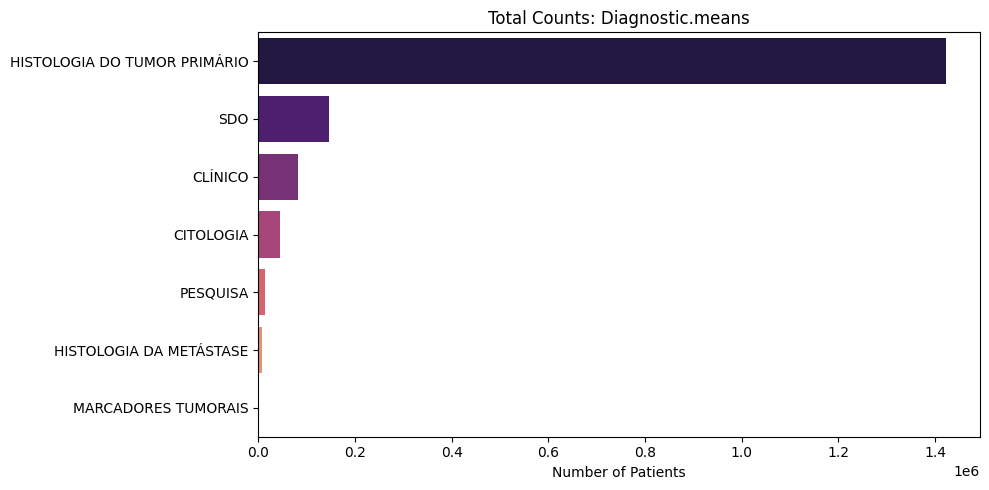

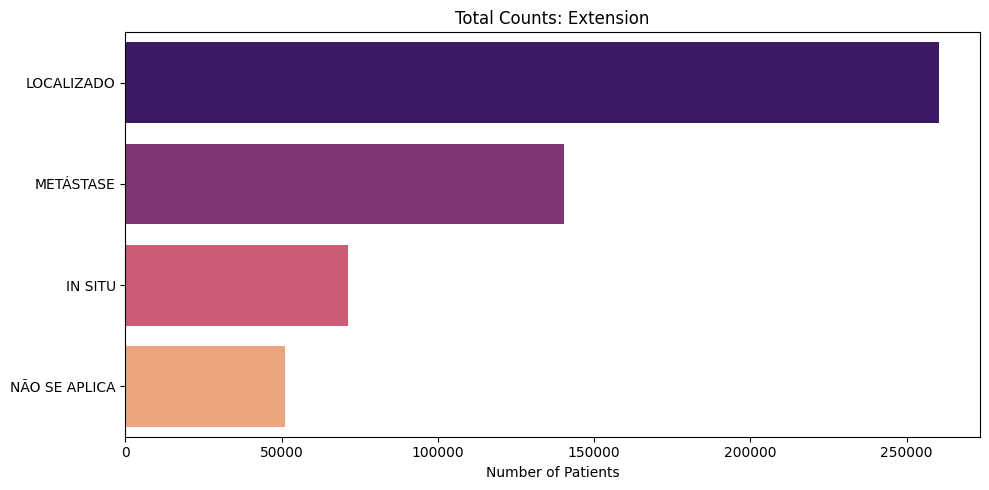

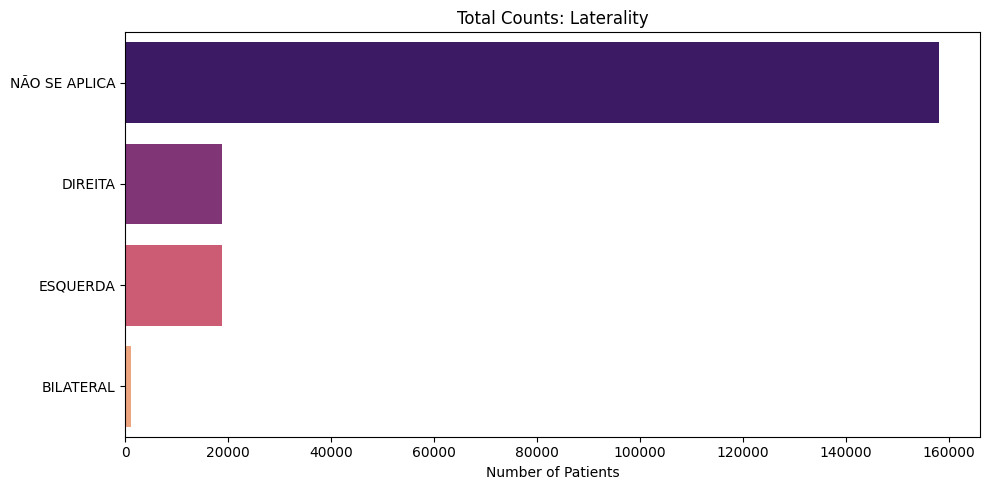

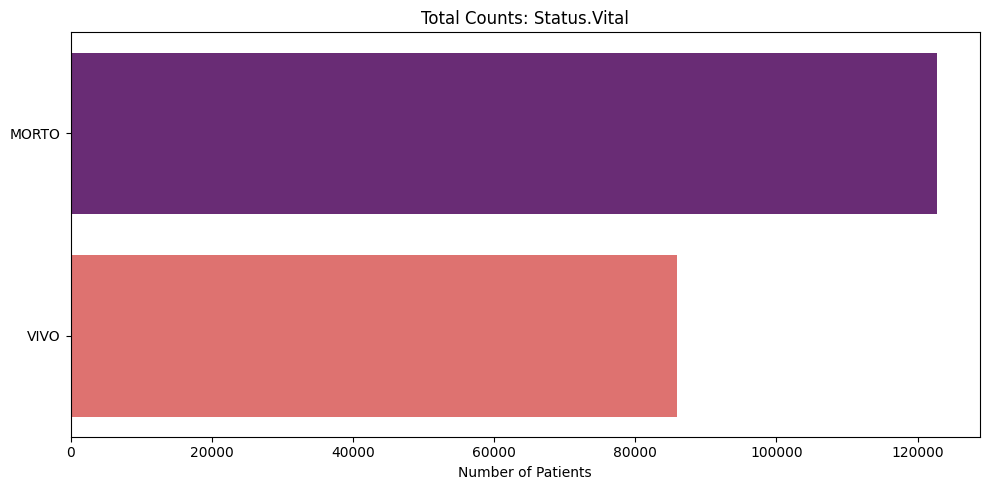

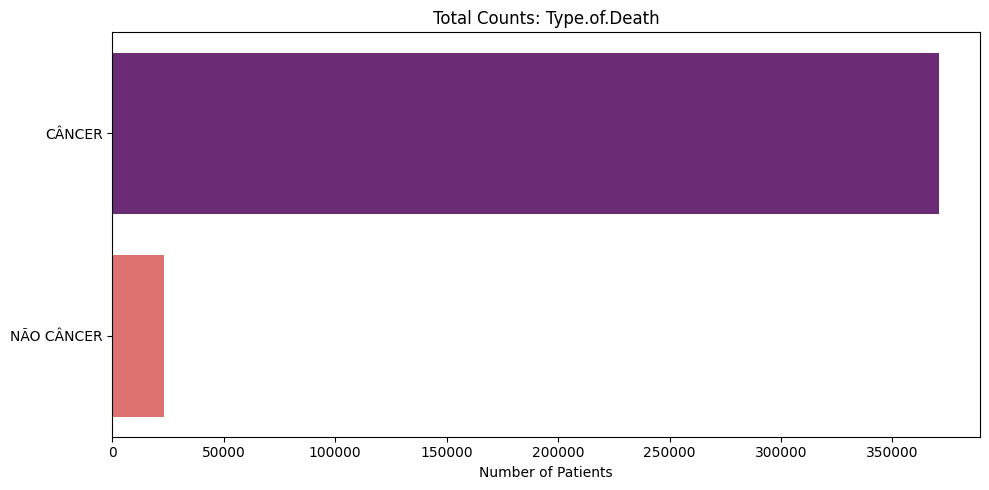

In [ ]:
prefixes = ['Gender', 'Raca.Color', 'Degree.of.Education', 'State.Civil', 
            'Diagnostic.means', 'Extension', 'Laterality', 'Status.Vital', 'Type.of.Death']

for prefix in prefixes:
    cols = [c for c in df.columns if c.startswith(prefix)]
    if not cols: continue
        
    counts = df[cols].sum().sort_values(ascending=False)
    labels = [label.replace(f"{prefix}_", "") for label in counts.index]
    
    plt.figure(figsize=(10, 5))
    # FIX: Assign 'y' to 'hue' and set 'legend=False'
    sns.barplot(
        x=counts.values, 
        y=labels, 
        hue=labels, 
        palette="magma", 
        legend=False
    )
    
    plt.title(f"Total Counts: {prefix}")
    plt.xlabel("Number of Patients")
    plt.tight_layout()
    plt.show()

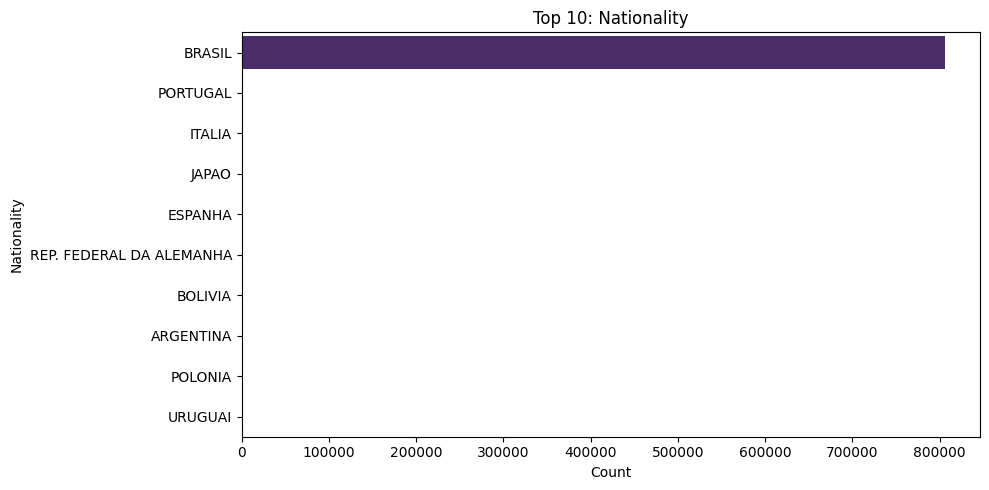

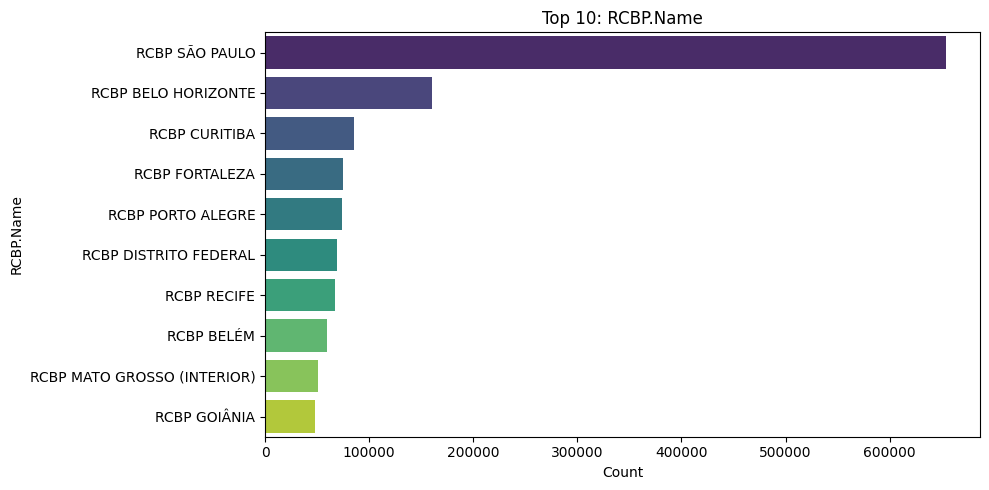

/var/folders/n2/lj0kdn5x5db8gsjp423jfpb80000gn/T/ipykernel_65675/3355149757.py:18: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/jamieconner/Desktop/dx699-02/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


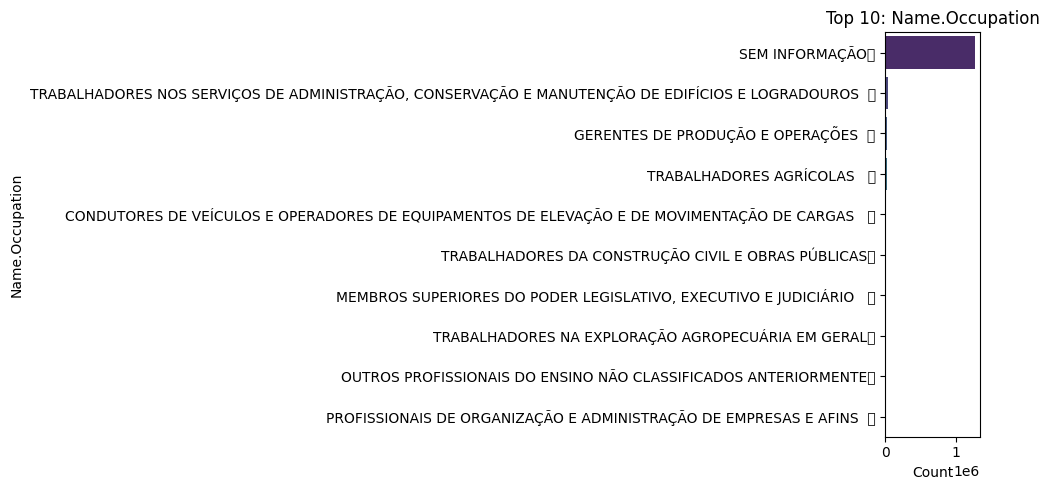

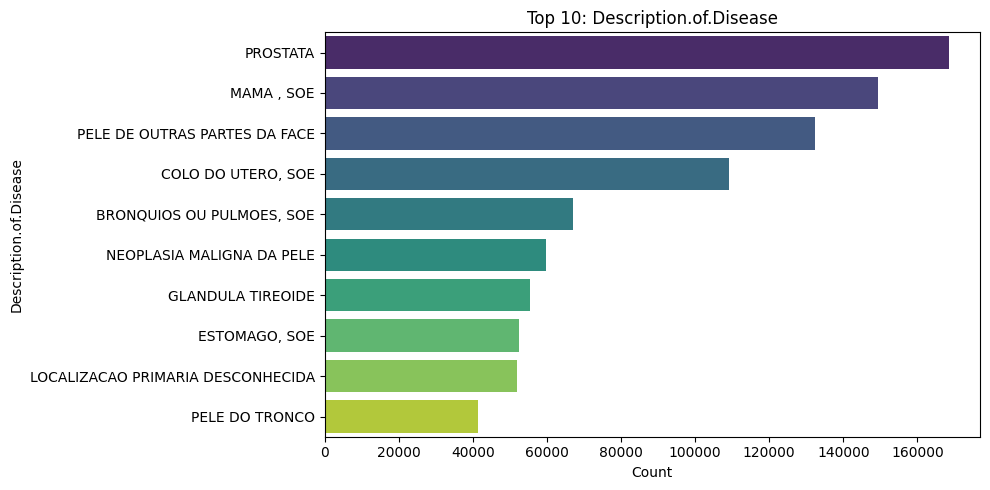

In [ ]:
string_cols = ['Nationality', 'RCBP.Name', 'Name.Occupation', 'Description.of.Disease']

for col in string_cols:
    plt.figure(figsize=(10, 5))
    top_10 = df[col].value_counts().head(10)
    
    # FIX: Assign 'y' (top_10.index) to 'hue' and set 'legend=False'
    sns.barplot(
        x=top_10.values, 
        y=top_10.index, 
        hue=top_10.index, 
        palette="viridis", 
        legend=False
    )
    
    plt.title(f"Top 10: {col}")
    plt.xlabel("Count")
    plt.tight_layout()
    plt.show()

# Find means, medians, and modes.

In [ ]:


# Generate the table
stats_targets = ['Age', 'Survival_Days']
summary_table = df_stats[stats_targets].agg(['mean', 'median'])


summary_table.loc['mode'] = df_stats[stats_targets].mode().iloc[0]


print(summary_table.T)

                     mean  median  mode
Age             64.941325    67.0  73.0
Survival_Days  398.045358     0.0   0.0


**Project Goal**

My goal is to develop a classification model to predict patient vital status (Alive vs. Deceased) using demographic data and diagnostic methods. I am specifically monitoring the diagnostic plots for instances where the red bars (Deceased) increase in proportion; these high-signal categories indicate features with a stronger correlation to mortality and will likely serve as the most important predictors for the model.
Data Exploration Q&A

1. **Are the data what you expect and are they likely to be usable?**

    The data is usable and fits expectations for a large-scale oncology dataset.

    There is a significant class imbalance with far more surviving patients than deceased ones, which is common in medical records and will need to be addressed during model training.

2. **What is the overall shape of the distributions?**

    Age: Roughly bell-shaped but slightly right-skewed.

    Survival Days: Heavily right-skewed, as most patients have shorter survival times compared to a small number of long-term survivors.

3. **Are there any outliers present?**

    Yes, clear outliers exist in the Age column, ranging from infants to patients over 100 years old.

    Survival Days also contains outliers consisting of patients who have lived significantly longer than the population average.

4. **How does the distribution change across different groups?**

    The distribution of Vital Status shifts noticeably depending on the diagnostic method.

    For example, the SDO group (Death Certificate Only) shows a much higher proportion of deceased patients, which makes sense as these cases are often only reported at the time of death.

5. **What are the minimum and maximum values represented?**

    While most features are Boolean (True/False), the numerical columns show a wide range:

        Age: Ranges from 0 to 100+.

        Survival Days: Ranges from 0 (diagnosis at time of death) to several thousand days.

6. **How do bin sizes affect the histograms?**

    Changing the bin size to 50 allowed for a more granular view, revealing specific peaks in the age of diagnosis that were smoothed over and hidden by smaller, wider bin widths.

7. **Does the distribution appear normal?**

    None of the features are perfectly normal. Age is the closest to a normal curve, but it still exhibits skew. All other categorical and survival data follow non-normal, skewed patterns.

# 4. Storytelling With Data graph

Reproduce any graph of your choice in p. 52-68 of the Storytelling With Data book as best you can.  (The second half of chapter two).  You do not have to get the exact data values right, just the overall look and feel.

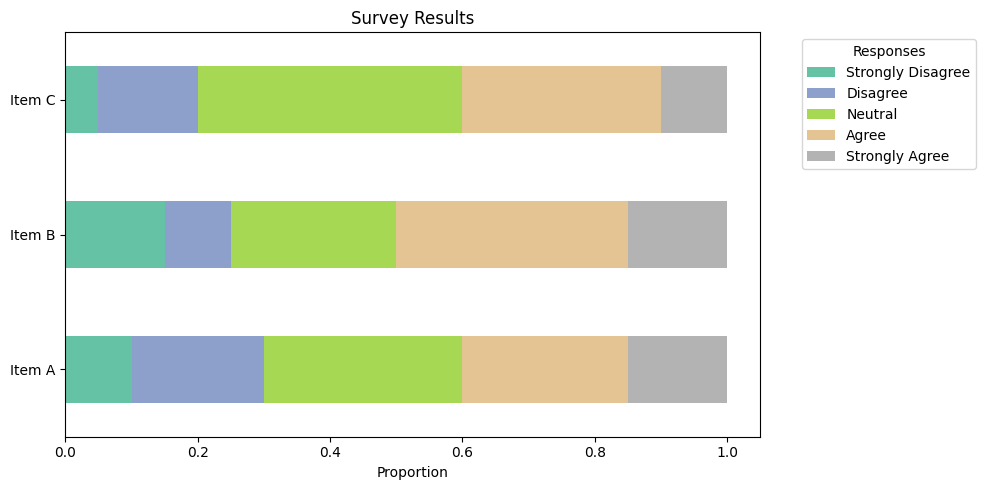

In [ ]:

data = {
    'Strongly Disagree': [10, 15, 5],
    'Disagree': [20, 10, 15],
    'Neutral': [30, 25, 40],
    'Agree': [25, 35, 30],
    'Strongly Agree': [15, 15, 10]
}
df = pd.DataFrame(data, index=['Item A', 'Item B', 'Item C'])


df_perc = df.div(df.sum(axis=1), axis=0) ### normalizes 


df_perc.plot(kind='barh', 
             stacked=True, 
             figsize=(10, 5), 
             colormap='Set2')

plt.title("Survey Results")
plt.xlabel("Proportion")
plt.legend(title="Responses", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()